In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt


from dataset.radio_galaxy_dataset.firstgalaxydata import FIRSTGalaxyData
from helpers import first_radio_galaxy_transform_val

In [2]:
ds = FIRSTGalaxyData(
    root=str("data"), selected_split="test",
    selected_classes=["FRI", "FRII", "Compact", "Bent"],
    input_data_list=["galaxy_data_h5.h5"],
    is_PIL=False, is_RGB=True,
    transform=first_radio_galaxy_transform_val,
)
raw = np.asarray(ds[120], dtype=np.float32)
img01 = (raw + 1) / 2
x = torch.from_numpy(img01).float()
F = torch.fft.fftshift(torch.fft.fft2(x))

In [3]:
def conj_partner(S):
    return torch.roll(torch.flip(S, dims=(-2, -1)), shifts=(1, 1), dims=(-2, -1))

def make_hermitian_or(S):
    S = torch.fft.ifftshift(S)
    return torch.fft.fftshift(torch.logical_or(S > 0, conj_partner(S) > 0).float())

def make_hermitian_and(S):
    S = torch.fft.ifftshift(S)
    return torch.fft.fftshift(torch.logical_and(S > 0, conj_partner(S) > 0).float())

In [4]:
M = torch.from_numpy(np.load("uv_coverages/VLA_mask_150.npy")).float()

def recon(mask):
    return torch.fft.ifft2(torch.fft.ifftshift(mask * F))

def imag_ratio(r):
    return (r.imag.pow(2).mean().sqrt() / r.real.pow(2).mean().sqrt()).item()

variants = {
    "BASE": M,
    "OR": make_hermitian_or(M),
    "AND": make_hermitian_and(M),
}

for name, mask in variants.items():
    r = recon(mask)
    print(f"{name:10s} kept={int((mask > 0).sum()):5d} max_imag = {r.imag.max()} max_real= {r.real.max()}")

BASE       kept= 2852 max_imag = 0.05498487874865532 max_real= 0.2905501425266266
OR         kept= 4675 max_imag = 1.8539100921088902e-08 max_real= 0.4789574444293976
AND        kept= 1029 max_imag = 5.395605295888117e-09 max_real= 0.10959853231906891


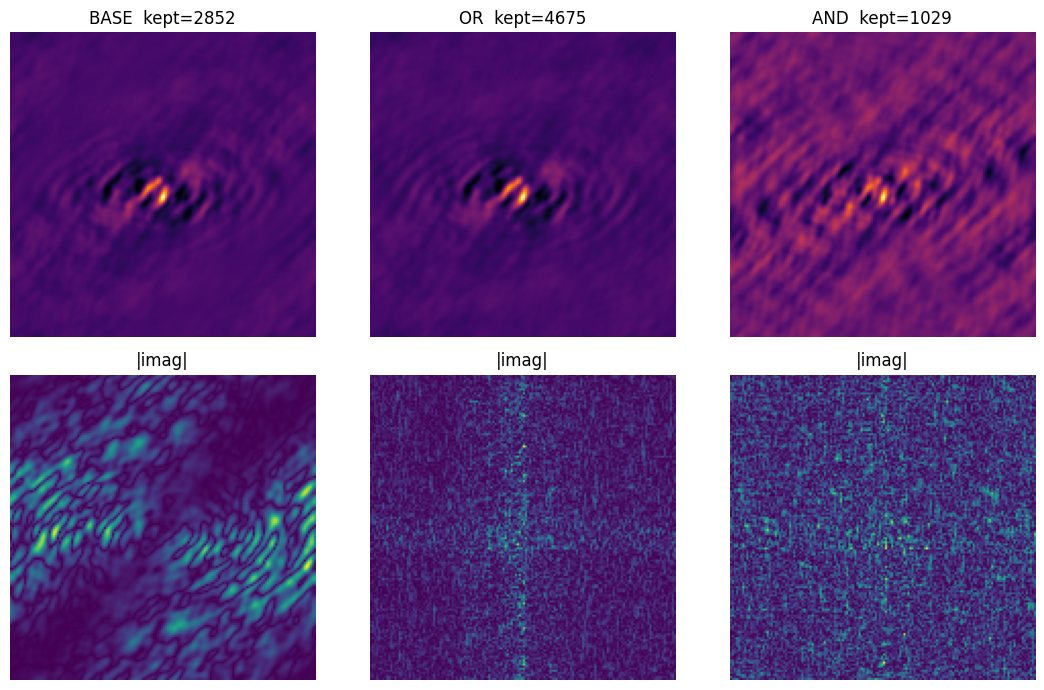

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for j, (name, mask) in enumerate(variants.items()):
    r = recon(mask)
    axes[0, j].imshow(r.real.numpy(), cmap="inferno")
    axes[0, j].set_title(f"{name}  kept={int((mask > 0).sum())}")
    axes[0, j].axis("off")
    axes[1, j].imshow(r.imag.abs().numpy(), cmap="viridis")
    axes[1, j].set_title(f"|imag|")
    axes[1, j].axis("off")
plt.tight_layout()
plt.show()

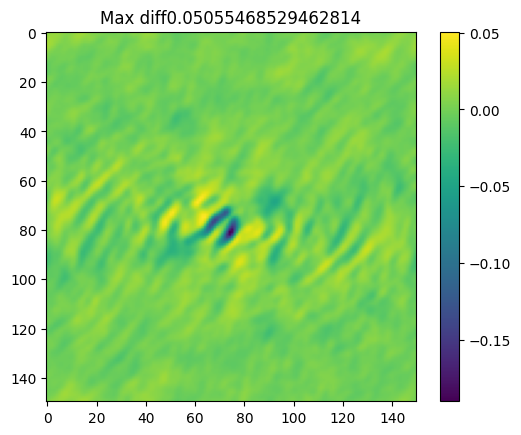

In [6]:
r_base = recon(M)
r_OR = recon(make_hermitian_or(M))
plt.imshow(r_base.real.numpy()-r_OR.real.numpy())
plt.title(f"Max diff{(r_base.real.numpy()-r_OR.real.numpy()).max()}")
plt.colorbar()
plt.show()

In [7]:
def roundtrip(image, mask, n):
    seq = [image]
    cur = image
    for _ in range(n):
        cur = torch.fft.ifft2(torch.fft.ifftshift(mask * torch.fft.fftshift(torch.fft.fft2(cur)))).real
        seq.append(cur)
    return seq

N_ITERS = 25
chains = {name: roundtrip(x, mask, N_ITERS) for name, mask in variants.items()}

for name, seq in chains.items():
    step = [(seq[k + 1] - seq[k]).norm().item() / seq[k].norm().item() for k in range(1, len(seq) - 1)]
    print(f"{name:5s} iter1->2={step[0]:.3e}  iter{N_ITERS-1}->{N_ITERS}={step[-1]:.3e}  total iter1->{N_ITERS}={(seq[-1] - seq[1]).norm().item() / seq[1].norm().item():.3e}")

BASE  iter1->2=3.663e-01  iter24->25=1.672e-07  total iter1->25=7.326e-01
OR    iter1->2=1.534e-07  iter24->25=1.451e-07  total iter1->25=1.727e-06
AND   iter1->2=1.538e-07  iter24->25=1.490e-07  total iter1->25=1.803e-06


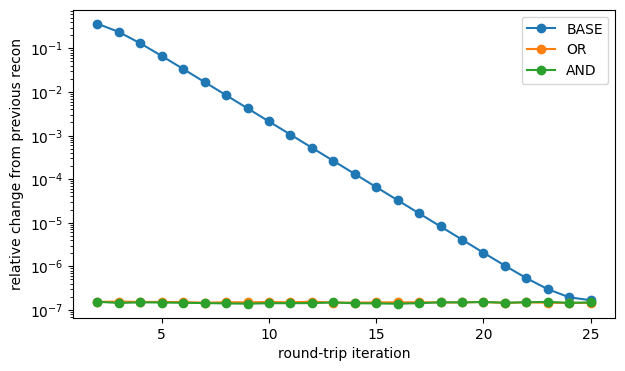

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, seq in chains.items():
    step = [(seq[k + 1] - seq[k]).norm().item() / seq[k].norm().item() for k in range(1, len(seq) - 1)]
    ax.semilogy(range(2, len(seq)), step, marker="o", label=name)
ax.set_xlabel("round-trip iteration")
ax.set_ylabel("relative change from previous recon")
ax.legend()
plt.show()

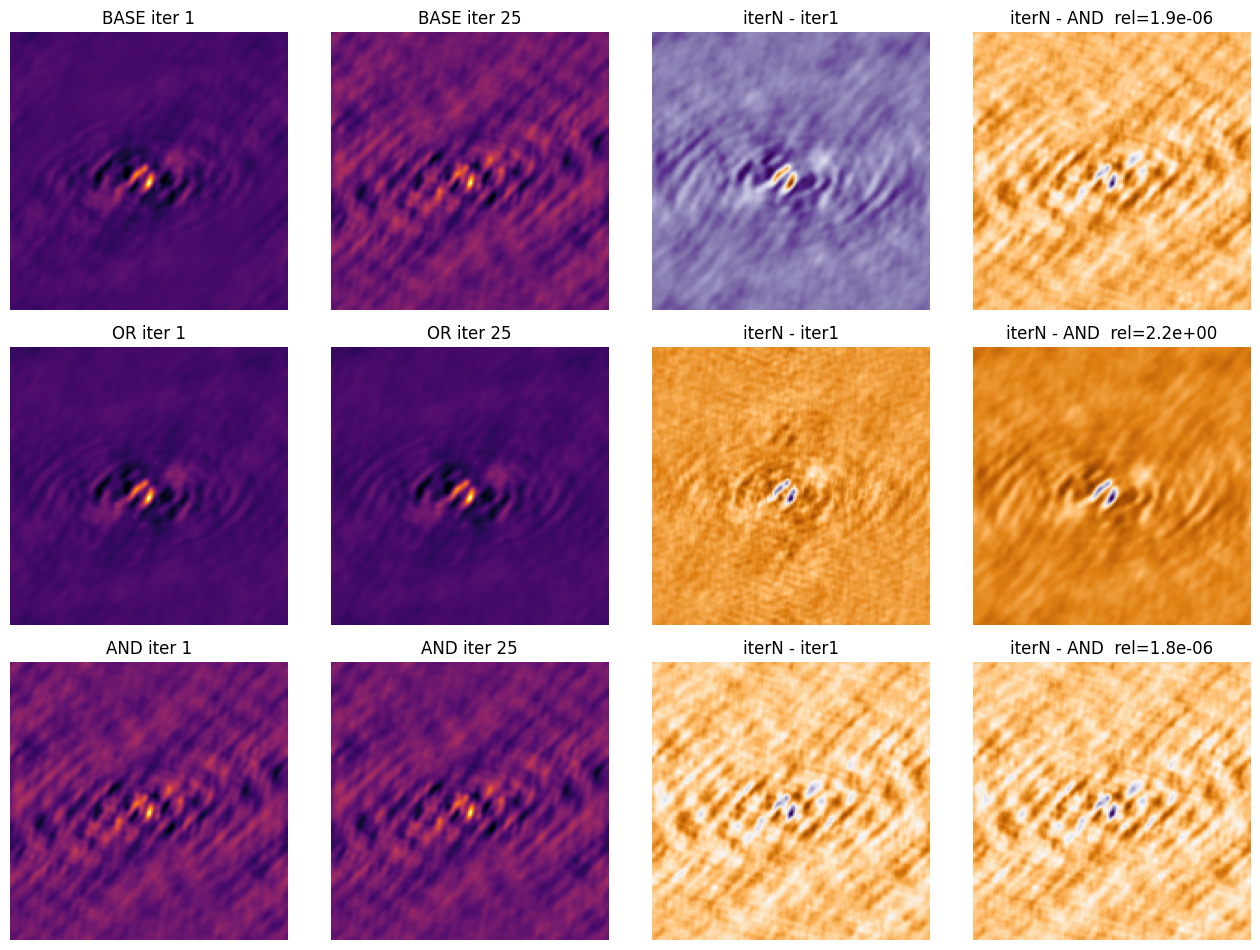

In [9]:
and_recon = recon(make_hermitian_and(M)).real
fig, axes = plt.subplots(len(chains), 4, figsize=(13, 3.2 * len(chains)))
for i, (name, seq) in enumerate(chains.items()):
    d = (seq[-1] - and_recon).norm().item() / and_recon.norm().item()
    axes[i, 0].imshow(seq[1].numpy(), cmap="inferno")
    axes[i, 0].set_title(f"{name} iter 1")
    axes[i, 1].imshow(seq[-1].numpy(), cmap="inferno")
    axes[i, 1].set_title(f"{name} iter {N_ITERS}")
    axes[i, 2].imshow((seq[-1] - seq[1]).numpy(), cmap="PuOr")
    axes[i, 2].set_title("iterN - iter1")
    axes[i, 3].imshow((seq[-1] - and_recon).numpy(), cmap="PuOr")
    axes[i, 3].set_title(f"iterN - AND  rel={d:.1e}")
    for a in axes[i]:
        a.axis("off")
plt.tight_layout()
plt.show()